In [20]:
import os
explanations_dir = '/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_yes_gsam_grounding_random_100/explanations_test'
listdir_explanations = os.listdir(explanations_dir)

question_id = '1958479'
# get the explanation file for the question where the question id is 1958479
explanation_file = [file for file in listdir_explanations if question_id in file][0]
print(explanation_file)

explanations_7_5_1958479.pkl


In [21]:
import pickle
path = os.path.join(explanations_dir, explanation_file)
with open(path, 'rb') as f:
    explanations = pickle.load(f)

In [22]:
explanations.keys()

dict_keys(['question_ids', 'questions', 'promptified_questions', 'answers', 'full_answers', 'image_ids', 'image_paths', 'response_0', 'response_1', 'response_2', 'response_3', 'response_4', 'response_5', 'response_6', 'response_7', 'response_8', 'response_9', 'response_10', 'response_11', 'response_12', 'response_13', 'response_14', 'response_15', 'response_16', 'response_17', 'response_18', 'response_19'])

In [23]:
print(' No of scores of the logits', len(explanations['response_0']['outputs'].scores))
print(' No of sequences', explanations['response_0']['generated_token_ids'].shape)

 No of scores of the logits 39
 No of sequences torch.Size([1, 39])


In [16]:
explanations['response_0'].keys()

for key, value in explanations['response_0'].items():
    print(key, value)

prompt USER:<image>
        Are there tables or bowls?
        Give your answer in JSON format where the keys are answer(one word answer), explanation( explain your answer in one short sentence), and your confidence(varies between 0 to 1).
        
outputs GenerateDecoderOnlyOutput(sequences=tensor([[    1,  3148,  1001, 29901, 32000, 29871,    13,  4706,  4683,   727,
          6131,   470, 12580,  3137, 29973,    13,  4706, 25538,   596,  1234,
           297,  4663,  3402,   988,   278,  6611,   526,  1234, 29898,   650,
          1734,  1234,   511,  8252, 29898,  5649,   596,  1234,   297,   697,
          3273, 10541,   511,   322,   596, 16420, 29898,  1707,   583,  1546,
         29871, 29900,   304, 29871, 29896,   467,    13,   308, 29896,   426,
            13,   418,   376, 12011,  1115,   376,  3782,   613,    13,   418,
           376,   735,  9018,   362,  1115,   376,  3112,   338,   871,   278,
          9687,   373,   278, 15284,   613,    13,   418,   376,  5527,  50

In [24]:
outputs = explanations['response_0']['outputs']
generated_token_ids = explanations['response_0']['generated_token_ids']

print('No of scores of the logits', len(outputs.scores))
print('No of sequences', generated_token_ids.shape)

No of scores of the logits 39
No of sequences torch.Size([1, 39])


In [25]:
outputs.scores[0].shape

torch.Size([1, 32064])

In [26]:
explanations['response_0']['decoded_outputs']

'1 {\n      "answer": "No",\n      "explanation": "It is only the food on the plate",\n      "confidence": 1\n    }'

In [31]:
def get_json_from_response(response):
    """
    response is usually a string which has lot of extrac characters instead of the json, like as below:
    '1 {\n      "answer": "No",\n      "explanation": "It is only the food on the plate",\n      "confidence": 1\n    }'
    """
    start_token = response.find('{')
    end_token = response.rfind('}')
    response_json = response[start_token:end_token+1]
    
    return response_json

In [32]:
get_json_from_response(explanations['response_0']['decoded_outputs'])

'{\n      "answer": "No",\n      "explanation": "It is only the food on the plate",\n      "confidence": 1\n    }'

In [33]:
def get_semantic_entropy(question, explanation_with_log_probs):
    """
    Calculates the semantic entropy for a given question and its explanations.

    Semantic entropy is computed by:
    1. Clustering explanations based on bidirectional entailment using an NLI model.
    2. Calculating the entropy over the distribution of these clusters.

    Args:
        question (str): The question for which the explanations are generated.
        explanation_with_log_probs (dict): A dictionary where keys are explanations (str)
                                           and values are their corresponding log probabilities (float).

    Returns:
        float: The semantic entropy value.
    """
    import torch
    from transformers import DebertaTokenizer, DebertaForSequenceClassification
    import math

    # Load the NLI model and tokenizer
    tokenizer = DebertaTokenizer.from_pretrained('microsoft/deberta-large-mnli')
    model = DebertaForSequenceClassification.from_pretrained('microsoft/deberta-large-mnli')
    model.eval()

    # Extract explanations and their log probabilities
    explanations = list(explanation_with_log_probs.keys())
    log_probs = list(explanation_with_log_probs.values())

    # Convert log probabilities to probabilities
    probs = [math.exp(lp) for lp in log_probs]

    # Normalize probabilities to ensure they sum to 1
    total_prob = sum(probs)
    probs = [p / total_prob for p in probs]

    # Initialize clusters
    clusters = []

    for idx, explanation in enumerate(explanations):
        assigned = False
        for cluster in clusters:
            representative = cluster[0]  # Choose the first explanation as the representative

            # Prepare premises for NLI
            premise1 = f"{question} {explanation}"
            premise2 = f"{question} {representative}"

            # Encode the pair for NLI: premise -> hypothesis
            inputs1 = tokenizer.encode_plus(premise1, premise2, return_tensors='pt', truncation=True)
            inputs2 = tokenizer.encode_plus(premise2, premise1, return_tensors='pt', truncation=True)

            with torch.no_grad():
                logits1 = model(**inputs1).logits
                logits2 = model(**inputs2).logits

            # Get predicted labels
            pred1 = torch.argmax(logits1, dim=1).item()  # 0: contradiction, 1: neutral, 2: entailment
            pred2 = torch.argmax(logits2, dim=1).item()

            # Check for bidirectional entailment
            if pred1 == 2 and pred2 == 2:
                cluster.append(explanation)
                assigned = True
                break  # Move to the next explanation after assigning to a cluster

        if not assigned:
            # Create a new cluster with the current explanation as its representative
            clusters.append([explanation])

    # Compute the probability of each cluster by summing probabilities of its explanations
    cluster_probs = []
    for cluster in clusters:
        cluster_prob = sum(probs[explanations.index(exp)] for exp in cluster)
        cluster_probs.append(cluster_prob)

    # Compute semantic entropy: SE(x) = -sum(p(c) * log(p(c)))
    entropy = -sum(p * math.log(p) for p in cluster_probs if p > 0)

    return entropy, clusters

In [34]:
# Example usage
question = "What is the capital of France?"
explanation_with_log_probs = {
    "Paris is the capital of France.": -0.2,
    "The capital of France is Paris.": -0.25,
    "Paris.": -1.5,
    "Lyon is a major city in France.": -2.3
}

entropy = get_semantic_entropy(question, explanation_with_log_probs)
print(f"Semantic Entropy: {entropy}")

/opt/conda/envs/llava/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/opt/conda/envs/llava/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']
- This IS expected if you are initializing Deberta

Semantic Entropy: 0.20492281966477813


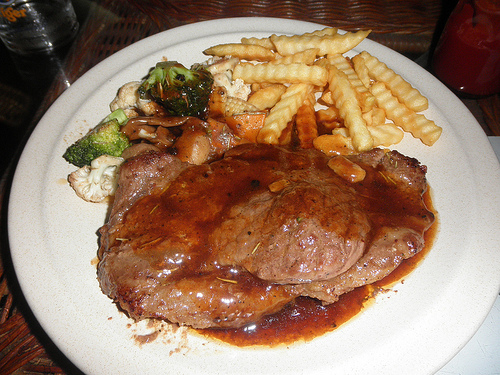

Are there tables or bowls?
USER:<image>
        Are there tables or bowls?
        Give your answer in JSON format where the keys are answer(one word answer), explanation( explain your answer in one short sentence), and your confidence(varies between 0 to 1).
        
yes
Response: response_0
Explanation: 1 {
      "answer": "No",
      "explanation": "It is only the food on the plate",
      "confidence": 1
    }
Response: response_1
Explanation: 1, 1.0, What is the color of the pasta that sticks in the mushrooms during the cooking process.
Response: response_2
Explanation: 知りません
Response: response_3
Explanation: {"table": "no"}
Response: response_4
Explanation: 
        {
          "answer": "no",
          "explanation": "Soup or a salad is being served for the meal",
          "confidence": 0.87
        }
Response: response_5
Explanation: {"table": true}
Response: response_6
Explanation: {
           "answer": "yes",
           "explanation": "This is visible in the right corner of

In [11]:
from PIL import Image
# image 
image_id = explanations['image_ids'][0]
# load the image
image_path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/dataset/GQA/images/' + image_id + '.jpg'
img = Image.open(image_path)
# display the image
img.show()
# question
question = explanations['questions'][0]
print(question)
# print promtified question
print(explanations['promptified_questions'][0])
# answer
answer = explanations['answers'][0]
print(answer)

# now print the explanation of each response
for key, value in explanations.items():
    if 'response' in key:
        print('Response:', key)
        print('Explanation:', value['decoded_outputs'])

In [3]:
import pickle
import os

path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_yes_gsam_grounding_random_100/uncertainty/uncertainty_scores_baseline.pkl'
with open(path, 'rb') as f:
    uncertainty_scores = pickle.load(f)

In [4]:
uncertainty_scores

{'1958479': {'predictive_entropy': -0.045795364643515815,
  'lexical_similarity': 0.1858115429544001,
  'semantic_entropy': 0.0011374008563675298,
  'num_clusters': 7},
 '08849239': {'predictive_entropy': -0.06728131237428511,
  'lexical_similarity': 0.25496983661092787,
  'semantic_entropy': 0.00016486913947605112,
  'num_clusters': 6},
 '00574814': {'predictive_entropy': -0.0008134473264731631,
  'lexical_similarity': 0.2385932006317418,
  'semantic_entropy': 0.26894289872451677,
  'num_clusters': 9},
 '08723090': {'predictive_entropy': -1.4398466270192073e-06,
  'lexical_similarity': 0.1870892420496133,
  'semantic_entropy': 0.6726336269189053,
  'num_clusters': 9},
 '18799787': {'predictive_entropy': -0.002509076128411299,
  'lexical_similarity': 0.3457040032863281,
  'semantic_entropy': 0.10318538427458687,
  'num_clusters': 6},
 '09879462': {'predictive_entropy': -0.3376499298180157,
  'lexical_similarity': 0.3100529100529101,
  'semantic_entropy': 0.00043981145481383104,
  'num_

In [1]:
# Load the grounding scores
path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_yes_gsam_grounding_random_100/uncertainty/uncertainty_random_100.pkl'
import pickle
with open(path, 'rb') as f:
    grounding_scores = pickle.load(f)

In [6]:
import os
root_dir_grounding = '/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_yes_gsam_grounding_random_100/grounding'
grounding_files = os.listdir(root_dir_grounding)
grounding_files[0]

'grounding_6_6_09775895.pkl'

In [7]:
path = os.path.join(root_dir_grounding, grounding_files[0])
with open(path, 'rb') as f:
    grounding = pickle.load(f)

/opt/conda/envs/llava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2024-10-09 17:06:57,403] [INFO] [real_accelerator.py:161:get_accelerator] Setting ds_accelerator to cuda (auto detect)


ModuleNotFoundError: No module named 'inference_utils'

In [10]:
path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_yes_gsam_grounding_random_100/uncertainty/uncertainty_scores_baseline.pkl'

import pickle
with open(path, 'rb') as f:
    uncertainty_scores = pickle.load(f)

In [11]:
uncertainty_scores

{'1958479': {'predictive_entropy': -0.045795364643515815,
  'lexical_similarity': 0.1858115429544001,
  'semantic_entropy': 0.0011374008563675298,
  'num_clusters': 7,
  'accuracy': 0.0},
 '08849239': {'predictive_entropy': -0.06728131237428511,
  'lexical_similarity': 0.25496983661092787,
  'semantic_entropy': 0.36627820844973136,
  'num_clusters': 6,
  'accuracy': 0.4},
 '00574814': {'predictive_entropy': -0.0008134473264731631,
  'lexical_similarity': 0.2385932006317418,
  'semantic_entropy': 0.5663373468103914,
  'num_clusters': 9,
  'accuracy': 0.09090909090909091},
 '08723090': {'predictive_entropy': -1.4398466270192073e-06,
  'lexical_similarity': 0.1870892420496133,
  'semantic_entropy': 0.84585808315304,
  'num_clusters': 9,
  'accuracy': 0.2},
 '18799787': {'predictive_entropy': -0.002509076128411299,
  'lexical_similarity': 0.3457040032863281,
  'semantic_entropy': 0.428527727687274,
  'num_clusters': 6,
  'accuracy': 0.25},
 '09879462': {'predictive_entropy': -0.33764992981

In [1]:
path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_yes_gsam_grounding_random_100/grounding_test/grounding_077759.pkl'
import pickle
with open(path, 'rb') as f:
    grounding = pickle.load(f)

ModuleNotFoundError: No module named 'inference_utils'

In [3]:
path = '/mnt/myebsvolume/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_yes_gsam_grounding_random_10000/explanations_00916859.pkl'
with open(path, 'rb') as f:
    exp = pickle.load(f)

In [1]:
import pickle

path = '/home/ec2-user/Multimodal-Uncertainty-Quantification/runs/uncertainty/uncertainty_scores_baseline.pkl'
with open(path, 'rb') as f:
    sc = pickle.load(f)

In [6]:
acc_list = []
for key, value in sc.items():
    acc_list.append(value['accuracy'])

In [11]:
# import matplotlib.pyplot as plt
# plt.plot(acc_list)

In [12]:
grounding_root_dir = '/mnt/myebsvolume/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_yes_gsam_grounding_random_10000/grounding/'

In [13]:
import os 
files = os.listdir(path=grounding_root_dir)

In [14]:
path = os.path.join(grounding_root_dir, files[0])
with open(path, 'rb') as f:
    sc = pickle.load(f)

ModuleNotFoundError: No module named 'inference_utils'